# Arbre de décision — Dataset Titanic

Objectif : prédire la survie des passagers du Titanic (`survived` = 1/0) à partir de leurs caractéristiques (classe, âge, sexe, tarif...).

Plan du notebook :
1. Chargement et exploration des données
2. Prétraitement (valeurs manquantes, encodage)
3. Entraînement d'un arbre de décision
4. Évaluation (accuracy, matrice de confusion, rapport de classification)
5. Visualisation de l'arbre et importance des variables
6. Réglage des hyperparamètres avec `GridSearchCV`
7. Courbe d'élagage (cost-complexity pruning)

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/svngoku/.local/pipx/venvs/pip/bin/python3.12 -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [7]:
# sns.get_dataset_names()

## 1. Chargement et exploration

In [9]:
df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.info()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

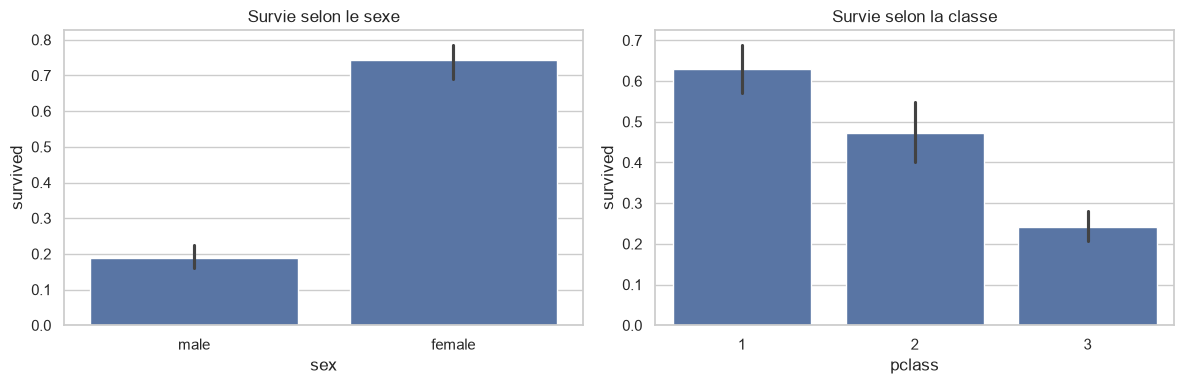

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0]).set_title("Survie selon le sexe")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1]).set_title("Survie selon la classe")
plt.tight_layout()
plt.show()

## 2. Prétraitement

On garde un sous-ensemble de variables exploitables et on impute les valeurs manquantes :
- `age` : imputation par la médiane
- `embarked` : imputation par le mode
- `deck` : trop de valeurs manquantes → supprimée
- Variables redondantes (`alive`, `class`, `who`, `alone`) → supprimées pour rester simple

In [12]:
cols = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
data = df[cols].copy()

data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

# Encodage One-hot
data = pd.get_dummies(data, columns=["sex", "embarked"], drop_first=True)

X = data.drop(columns="survived")
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
X.head()

Train: (712, 8) Test: (179, 8)


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 3. Entraînement d'un premier arbre

Sans contrainte, un arbre pousse jusqu'à mémoriser le training set (overfitting). On l'observe avec les scores train vs test.

In [13]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test  accuracy: {tree.score(X_test, y_test):.3f}")
print(f"Profondeur: {tree.get_depth()}, feuilles: {tree.get_n_leaves()}")

Train accuracy: 0.982
Test  accuracy: 0.821
Profondeur: 23, feuilles: 153


## 4. Évaluation

              precision    recall  f1-score   support

        Mort       0.84      0.88      0.86       110
     Survécu       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



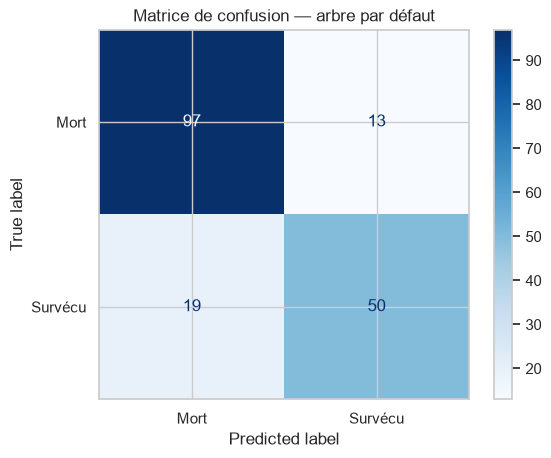

In [14]:
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Mort", "Survécu"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Mort", "Survécu"], cmap="Blues"
)
plt.title("Matrice de confusion — arbre par défaut")
plt.show()

## 5. Visualisation de l'arbre et importance des variables

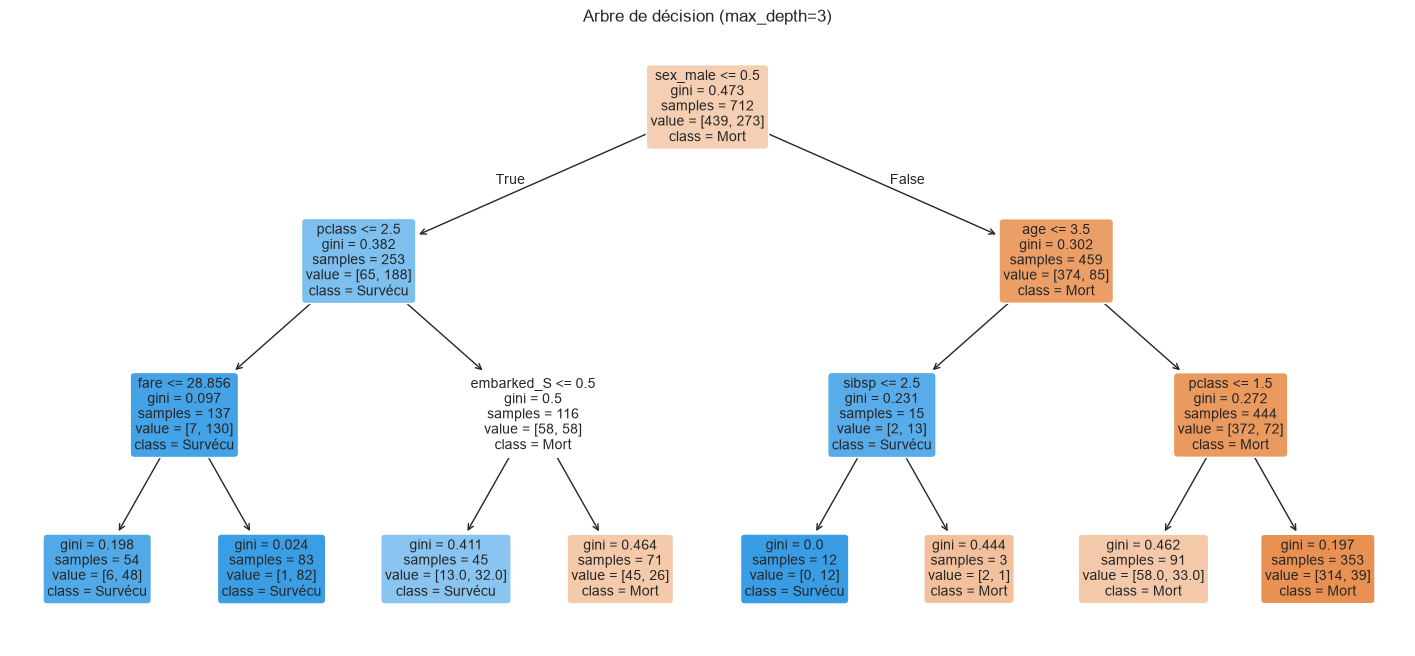

|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- class: 1
|   |   |--- fare >  28.86
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- embarked_S <= 0.50
|   |   |   |--- class: 1
|   |   |--- embarked_S >  0.50
|   |   |   |--- class: 0
|--- sex_male >  0.50
|   |--- age <= 3.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- class: 0
|   |--- age >  3.50
|   |   |--- pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- class: 0



In [15]:
# Version lisible : arbre limité en profondeur (sinon illisible)
small_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    small_tree,
    feature_names=list(X.columns),
    class_names=["Mort", "Survécu"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Arbre de décision (max_depth=3)")
plt.show()

# Règles en format texte
print(export_text(small_tree, feature_names=list(X.columns)))

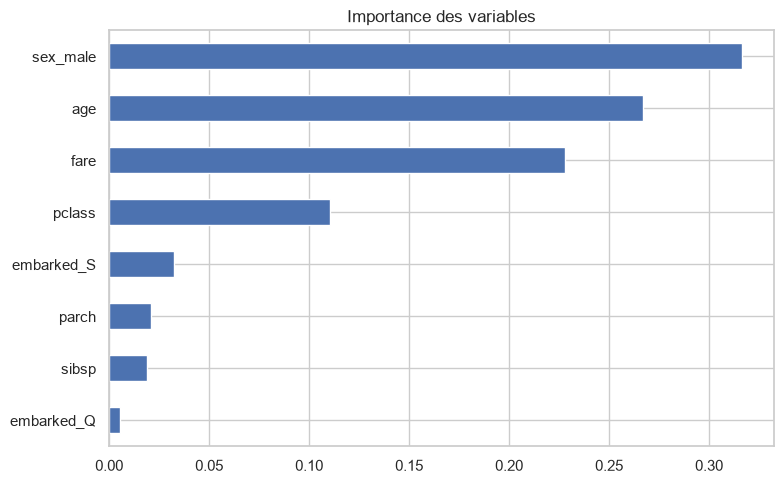

In [16]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values()

importances.plot(kind="barh", figsize=(8, 5), title="Importance des variables")
plt.tight_layout()
plt.show()

## 6. Réglage des hyperparamètres avec GridSearchCV

Les principaux leviers contre l'overfitting d'un arbre :
- `max_depth` : profondeur maximale
- `min_samples_leaf` : nb min d'échantillons par feuille
- `min_samples_split` : nb min d'échantillons pour diviser un nœud
- `criterion` : gini ou entropy

In [17]:
param_grid = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "criterion": ["gini", "entropy"],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print("Meilleurs paramètres:", grid.best_params_)
print(f"CV accuracy: {grid.best_score_:.3f}")

Meilleurs paramètres: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}
CV accuracy: 0.823


In [18]:
y_best = best_tree.predict(X_test)

print(f"Train accuracy: {best_tree.score(X_train, y_train):.3f}")
print(f"Test  accuracy: {accuracy_score(y_test, y_best):.3f}")
print()
print(classification_report(y_test, y_best, target_names=["Mort", "Survécu"]))

Train accuracy: 0.861
Test  accuracy: 0.765

              precision    recall  f1-score   support

        Mort       0.76      0.90      0.82       110
     Survécu       0.78      0.55      0.64        69

    accuracy                           0.77       179
   macro avg       0.77      0.73      0.73       179
weighted avg       0.77      0.77      0.76       179



## 7. Courbe d'élagage (cost-complexity pruning)

Le paramètre `ccp_alpha` contrôle le compromis biais/variance : plus il est grand, plus l'arbre est élagué.

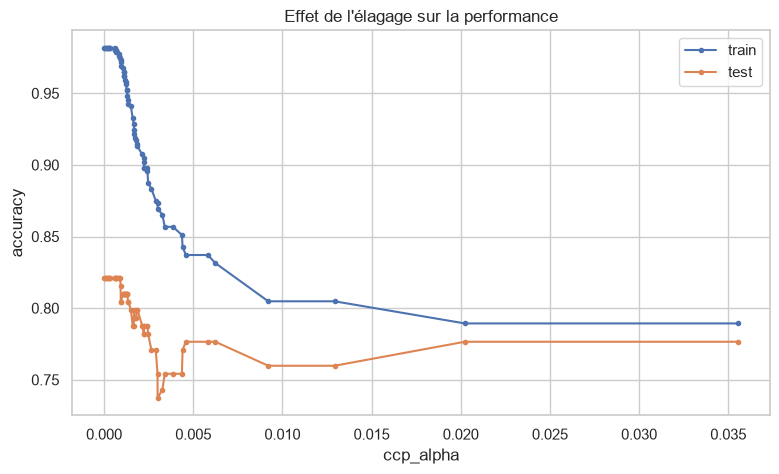

In [19]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # on retire le tronc seul

clfs = [
    DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a).fit(X_train, y_train)
    for a in ccp_alphas
]

train_scores = [c.score(X_train, y_train) for c in clfs]
test_scores = [c.score(X_test, y_test) for c in clfs]

plt.figure(figsize=(9, 5))
plt.plot(ccp_alphas, train_scores, marker=".", label="train")
plt.plot(ccp_alphas, test_scores, marker=".", label="test")
plt.xlabel("ccp_alpha")
plt.ylabel("accuracy")
plt.legend()
plt.title("Effet de l'élagage sur la performance")
plt.show()

## Pistes d'amélioration

- Ingénierie de variables : `family_size = sibsp + parch + 1`, `is_child = age < 12`, extraction du titre depuis `name`
- Imputation plus fine de l'âge (par classe ou via un estimateur)
- Comparer avec une forêt aléatoire (`RandomForestClassifier`) ou du boosting (`GradientBoostingClassifier`, `XGBoost`)
- Tracer la courbe ROC / calculer l'AUC